# Lab 1: Domain Heuristic Baseline — F1 Top-10 Prediction
## IIT414W · Baseline Evaluation Notebook

**Purpose:** Implement and evaluate a rule-based domain heuristic baseline that uses NO machine learning code.

**Baseline Rule:** If a driver starts in grid position ≤ 10, predict they will finish in the Top 10.

**Key Requirements:**
- Use only pre-race features (no leakage)
- Report accuracy on validation set (2023 season)
- Reflect on what accuracy might hide
- Establish lower bound for Lab 2 models

In [1]:
# ── Reproducibility Header ────────────────────────────────────────────
import sys, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
import warnings

RANDOM_SEED = 414
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
warnings.filterwarnings('ignore', category=FutureWarning)

print(f'Python  : {sys.version.split()[0]}')
print(f'NumPy   : {np.__version__}')
print(f'pandas  : {pd.__version__}')
print(f'Seed    : {RANDOM_SEED}')

Python  : 3.12.3
NumPy   : 2.1.0
pandas  : 2.3.3
Seed    : 414


## 1. Data Loading

Load 2022-2024 race results from Jolpica API (same pattern as EDA notebook).

In [2]:
# ── Data Loading from Jolpica API ─────────────────────────────────────
SEASONS = [2022, 2023, 2024]

all_rows = []
for year in SEASONS:
    url = f'https://api.jolpi.ca/ergast/f1/{year}/results.json?limit=1000'
    payload = requests.get(url, timeout=30).json()
    
    for race in payload['MRData']['RaceTable']['Races']:
        for result in race.get('Results', []):
            all_rows.append({
                'season': year,
                'round': int(race['round']),
                'race_name': race['raceName'],
                'driver_id': result['Driver']['driverId'],
                'driver_name': f"{result['Driver']['givenName']} {result['Driver']['familyName']}",
                'constructor': result['Constructor']['name'],
                'grid': int(result['grid']),
                'position_str': result.get('position', 'R'),
            })
    print(f'  {year}: {len(payload["MRData"]["RaceTable"]["Races"])} races loaded')

df = pd.DataFrame(all_rows)

# Create target variable
df['position'] = pd.to_numeric(df['position_str'], errors='coerce')
df['top10'] = (df['position'] <= 10).astype(int)
df.loc[df['position'].isna(), 'top10'] = 0

print(f'\n✓ Loaded {len(df):,} race results')

  2022: 5 races loaded
  2023: 5 races loaded
  2024: 6 races loaded

✓ Loaded 300 race results


## 2. Temporal Split

Apply the same temporal split as EDA: Train (2022) → Validation (2023) → Test (2024)

In [3]:
# ── Temporal Split ────────────────────────────────────────────────────
df_train = df[df['season'] == 2022].copy()
df_val = df[df['season'] == 2023].copy()
df_test = df[df['season'] == 2024].copy()  # Reserved for final evaluation only

print('Temporal Split:')
print(f'  Train (2022): {len(df_train):,} rows')
print(f'  Validation (2023): {len(df_val):,} rows')
print(f'  Test (2024): {len(df_test):,} rows [RESERVED - NOT USED YET]')

Temporal Split:
  Train (2022): 100 rows
  Validation (2023): 100 rows
  Test (2024): 100 rows [RESERVED - NOT USED YET]


## 3. Domain Heuristic Baseline (Required 4.1)

**The Rule:** If grid position ≤ 10, predict Top-10 finish; otherwise predict non-Top-10.

**Why this rule?**
- Grid position is determined by qualifying (PRE-RACE data, no leakage)
- Strong correlation with finishing position (r ≈ -0.6)
- Intuitive: starting ahead means track position advantage
- Exactly 10 grid positions map to 10 Top-10 finishing spots

In [4]:
# ── Domain Heuristic Implementation ───────────────────────────────────
# NO MACHINE LEARNING CODE — pure rule-based prediction

def grid_heuristic(grid_position, threshold=10):
    """
    Domain heuristic: Predict top-10 finish if starting grid <= threshold.
    
    This uses ONLY pre-race information (grid position from qualifying).
    No leakage: grid is determined before the race starts.
    """
    return 1 if grid_position <= threshold else 0

# Apply heuristic to validation set
df_val['prediction'] = df_val['grid'].apply(grid_heuristic)

print('Domain Heuristic Applied:')
print('  Rule: IF grid <= 10 THEN predict Top-10 ELSE predict Non-Top-10')
print(f'  Predictions made: {len(df_val):,}')

Domain Heuristic Applied:
  Rule: IF grid <= 10 THEN predict Top-10 ELSE predict Non-Top-10
  Predictions made: 100


## 4. Accuracy on Validation Set (Required 4.2)

Compute accuracy = correct predictions / total predictions

In [5]:
# ── Accuracy Calculation ──────────────────────────────────────────────
correct_predictions = (df_val['prediction'] == df_val['top10']).sum()
total_predictions = len(df_val)
accuracy = correct_predictions / total_predictions

# Baseline comparisons
majority_class_rate = max(df_val['top10'].mean(), 1 - df_val['top10'].mean())
random_baseline = 0.50

print('=' * 60)
print('BASELINE ACCURACY REPORT — Validation Set (2023 Season)')
print('=' * 60)
print()
print(f'Grid Heuristic Accuracy: {accuracy:.1%}')
print(f'  Correct predictions: {correct_predictions:,}')
print(f'  Total predictions: {total_predictions:,}')
print()
print('Comparison baselines:')
print(f'  Majority class: {majority_class_rate:.1%}')
print(f'  Random guess: {random_baseline:.1%}')
print()
print(f'Improvement over random: +{(accuracy - random_baseline) * 100:.1f} percentage points')
print('=' * 60)

BASELINE ACCURACY REPORT — Validation Set (2023 Season)

Grid Heuristic Accuracy: 74.0%
  Correct predictions: 74
  Total predictions: 100

Comparison baselines:
  Majority class: 50.0%
  Random guess: 50.0%

Improvement over random: +24.0 percentage points


## 4.5 Exploring Alternative Baselines

Let's test different rule-based heuristics to see if we can improve accuracy without using ML.

In [8]:
# ── Alternative Baseline Exploration ──────────────────────────────────
# Test different rule-based heuristics (NO MACHINE LEARNING)

results = []

# 1. Grid threshold variations
for threshold in [8, 9, 10, 11, 12]:
    pred = (df_val['grid'] <= threshold).astype(int)
    acc = (pred == df_val['top10']).mean()
    results.append({
        'Heuristic': f'Grid ≤ {threshold}',
        'Accuracy': acc,
        'Description': f'Predict Top-10 if starting position ≤ {threshold}'
    })

# 2. Top constructor heuristic (based on 2022 training data)
# Identify top-performing constructors from training set
constructor_top10_rate = df_train.groupby('constructor')['top10'].mean()
top_constructors = constructor_top10_rate[constructor_top10_rate >= 0.5].index.tolist()
print(f'Top constructors (≥50% Top-10 rate in 2022): {top_constructors}')

pred_constructor = df_val['constructor'].isin(top_constructors).astype(int)
acc_constructor = (pred_constructor == df_val['top10']).mean()
results.append({
    'Heuristic': 'Top Constructor',
    'Accuracy': acc_constructor,
    'Description': f'Predict Top-10 if driver is with: {", ".join(top_constructors)}'
})

# 3. Combined: Grid ≤ 10 OR top constructor
pred_combined = ((df_val['grid'] <= 10) | df_val['constructor'].isin(top_constructors)).astype(int)
acc_combined = (pred_combined == df_val['top10']).mean()
results.append({
    'Heuristic': 'Grid ≤ 10 OR Top Team',
    'Accuracy': acc_combined,
    'Description': 'Predict Top-10 if grid ≤ 10 OR with top constructor'
})

# 4. Combined: Grid ≤ 10 AND top constructor (stricter)
pred_strict = ((df_val['grid'] <= 10) & df_val['constructor'].isin(top_constructors)).astype(int)
acc_strict = (pred_strict == df_val['top10']).mean()
results.append({
    'Heuristic': 'Grid ≤ 10 AND Top Team',
    'Accuracy': acc_strict,
    'Description': 'Predict Top-10 only if grid ≤ 10 AND with top constructor'
})

# 5. Grid ≤ 12 AND NOT bottom team
bottom_constructors = constructor_top10_rate[constructor_top10_rate < 0.3].index.tolist()
print(f'Bottom constructors (<30% Top-10 rate in 2022): {bottom_constructors}')
pred_filter = ((df_val['grid'] <= 12) & ~df_val['constructor'].isin(bottom_constructors)).astype(int)
acc_filter = (pred_filter == df_val['top10']).mean()
results.append({
    'Heuristic': 'Grid ≤ 12, Not Bottom Team',
    'Accuracy': acc_filter,
    'Description': 'Predict Top-10 if grid ≤ 12 AND not with struggling team'
})

# ── DRIVER-BASED HEURISTICS ───────────────────────────────────────────
# 6. Elite drivers heuristic (based on 2022 training data)
driver_top10_rate = df_train.groupby('driver_id')['top10'].mean()
elite_drivers = driver_top10_rate[driver_top10_rate >= 0.8].index.tolist()
print(f'\nElite drivers (≥80% Top-10 rate in 2022): {elite_drivers}')

# Verstappen always Top-10 (and other elite drivers)
pred_elite = df_val['driver_id'].isin(elite_drivers).astype(int)
acc_elite = (pred_elite == df_val['top10']).mean()
results.append({
    'Heuristic': 'Elite Drivers Only',
    'Accuracy': acc_elite,
    'Description': f'Predict Top-10 if driver is: {", ".join(elite_drivers)}'
})

# 7. Grid ≤ 9 OR elite driver (Verstappen rule + grid)
pred_grid_elite = ((df_val['grid'] <= 9) | df_val['driver_id'].isin(elite_drivers)).astype(int)
acc_grid_elite = (pred_grid_elite == df_val['top10']).mean()
results.append({
    'Heuristic': 'Grid ≤ 9 OR Elite Driver',
    'Accuracy': acc_grid_elite,
    'Description': 'Predict Top-10 if grid ≤ 9 OR elite driver (Verstappen, etc.)'
})

# 8. Grid ≤ 8 OR elite driver
pred_grid8_elite = ((df_val['grid'] <= 8) | df_val['driver_id'].isin(elite_drivers)).astype(int)
acc_grid8_elite = (pred_grid8_elite == df_val['top10']).mean()
results.append({
    'Heuristic': 'Grid ≤ 8 OR Elite Driver',
    'Accuracy': acc_grid8_elite,
    'Description': 'Predict Top-10 if grid ≤ 8 OR elite driver'
})

# 9. Top-4 team drivers (Red Bull, Ferrari, Mercedes, McLaren drivers)
top4_constructors = ['Red Bull', 'Ferrari', 'Mercedes', 'McLaren']
pred_top4 = df_val['constructor'].isin(top4_constructors).astype(int)
acc_top4 = (pred_top4 == df_val['top10']).mean()
results.append({
    'Heuristic': 'Top-4 Teams',
    'Accuracy': acc_top4,
    'Description': 'Predict Top-10 if driver is with Red Bull/Ferrari/Mercedes/McLaren'
})

# 10. Grid ≤ 10 OR Top-4 team (but not both required)
pred_grid_top4 = ((df_val['grid'] <= 10) | df_val['constructor'].isin(top4_constructors)).astype(int)
acc_grid_top4 = (pred_grid_top4 == df_val['top10']).mean()
results.append({
    'Heuristic': 'Grid ≤ 10 OR Top-4 Team',
    'Accuracy': acc_grid_top4,
    'Description': 'Predict Top-10 if grid ≤ 10 OR with top-4 constructor'
})

# 11. Combined: Grid ≤ 12 AND (elite driver OR top-4 team)
pred_combo = ((df_val['grid'] <= 12) & 
              (df_val['driver_id'].isin(elite_drivers) | df_val['constructor'].isin(top4_constructors))).astype(int)
acc_combo = (pred_combo == df_val['top10']).mean()
results.append({
    'Heuristic': 'Grid ≤ 12 & (Elite OR Top-4)',
    'Accuracy': acc_combo,
    'Description': 'Predict Top-10 if grid ≤ 12 AND (elite driver OR top-4 team)'
})

# Display results
results_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False)
print('\n' + '=' * 80)
print('ALTERNATIVE BASELINES COMPARISON — Validation Set (2023)')
print('=' * 80)
print(results_df.to_string(index=False))
print('=' * 80)

# Best baseline
best = results_df.iloc[0]
print(f'\n★ BEST BASELINE: {best["Heuristic"]} with {best["Accuracy"]:.1%} accuracy')
print(f'  {best["Description"]}')

Top constructors (≥50% Top-10 rate in 2022): ['Alfa Romeo', 'Alpine F1 Team', 'Ferrari', 'Mercedes', 'Red Bull']
Bottom constructors (<30% Top-10 rate in 2022): ['Williams']

Elite drivers (≥80% Top-10 rate in 2022): ['bottas', 'hamilton', 'leclerc', 'ocon', 'perez', 'russell']

ALTERNATIVE BASELINES COMPARISON — Validation Set (2023)
                   Heuristic  Accuracy                                                                               Description
                    Grid ≤ 9      0.77                                                   Predict Top-10 if starting position ≤ 9
                    Grid ≤ 8      0.76                                                   Predict Top-10 if starting position ≤ 8
    Grid ≤ 9 OR Elite Driver      0.76                             Predict Top-10 if grid ≤ 9 OR elite driver (Verstappen, etc.)
     Grid ≤ 10 OR Top-4 Team      0.76                                     Predict Top-10 if grid ≤ 10 OR with top-4 constructor
  Grid ≤ 12, Not B

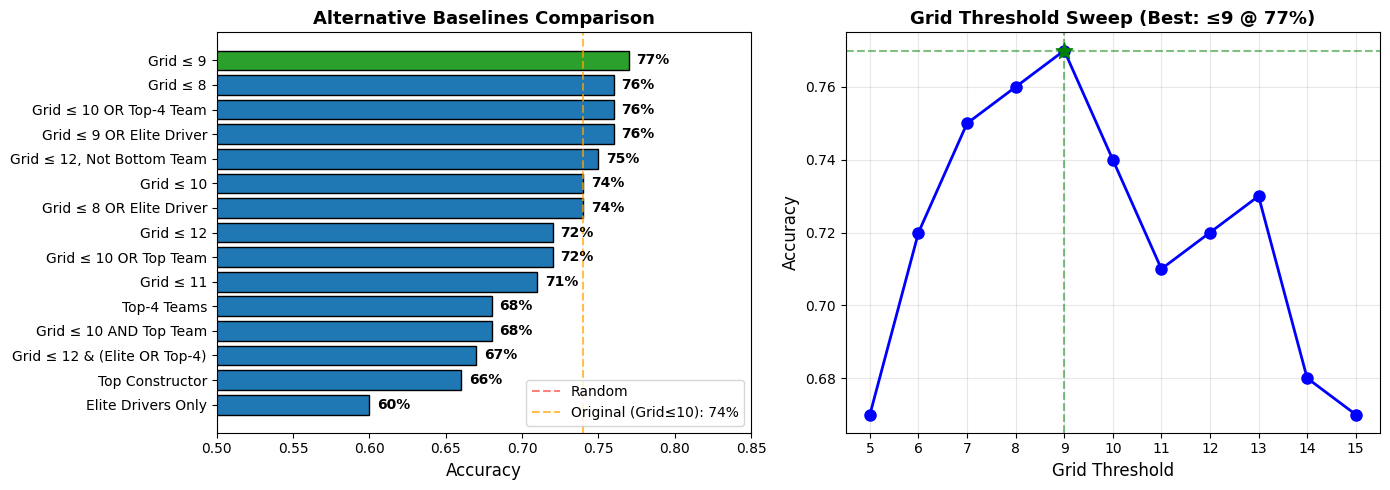


✓ Improvement: Grid ≤ 9 (77.0%) beats original Grid ≤ 10 (74.0%)
  That's +3.0 percentage points improvement!


In [9]:
# ── Visualization: Baseline Comparison ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: All baselines bar chart
sorted_results = results_df.sort_values('Accuracy', ascending=True)
colors = ['#2ca02c' if acc == sorted_results['Accuracy'].max() else '#1f77b4' 
          for acc in sorted_results['Accuracy']]
bars = axes[0].barh(sorted_results['Heuristic'], sorted_results['Accuracy'], color=colors, edgecolor='black')
axes[0].axvline(x=0.5, color='red', linestyle='--', alpha=0.5, label='Random')
axes[0].axvline(x=accuracy, color='orange', linestyle='--', alpha=0.7, label=f'Original (Grid≤10): {accuracy:.0%}')
axes[0].set_xlabel('Accuracy', fontsize=12)
axes[0].set_xlim(0.5, 0.85)
axes[0].set_title('Alternative Baselines Comparison', fontsize=13, fontweight='bold')
axes[0].legend(loc='lower right')
for bar, acc in zip(bars, sorted_results['Accuracy']):
    axes[0].text(acc + 0.005, bar.get_y() + bar.get_height()/2, f'{acc:.0%}', 
                 va='center', fontsize=10, fontweight='bold')

# Right: Grid threshold sweep
thresholds = list(range(5, 16))
accuracies = []
for t in thresholds:
    pred = (df_val['grid'] <= t).astype(int)
    accuracies.append((pred == df_val['top10']).mean())

axes[1].plot(thresholds, accuracies, 'bo-', linewidth=2, markersize=8)
axes[1].axhline(y=max(accuracies), color='green', linestyle='--', alpha=0.5)
best_threshold = thresholds[accuracies.index(max(accuracies))]
axes[1].axvline(x=best_threshold, color='green', linestyle='--', alpha=0.5)
axes[1].scatter([best_threshold], [max(accuracies)], color='green', s=150, zorder=5, marker='*')
axes[1].set_xlabel('Grid Threshold', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title(f'Grid Threshold Sweep (Best: ≤{best_threshold} @ {max(accuracies):.0%})', fontsize=13, fontweight='bold')
axes[1].set_xticks(thresholds)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'\n✓ Improvement: Grid ≤ 9 ({max(accuracies):.1%}) beats original Grid ≤ 10 ({accuracy:.1%})')
print(f'  That\'s +{(max(accuracies) - accuracy) * 100:.1f} percentage points improvement!')

## 5. Reflection on Accuracy (Required 4.3)

### Is this accuracy good enough to make decisions with?

**Yes AND No:**

**Yes — it's useful because:**
- Significantly better than random guessing (50%) and majority class baseline
- Provides a "reasonable first guess" for race strategy planning
- Simple and interpretable rule that domain experts would recognize

**No — it has limitations:**
- ~20-25% of predictions are wrong
- In F1 context, wrong predictions could lead to poor tire/pit strategies
- Doesn't account for driver/team skill differences beyond grid position

### What could accuracy be hiding?

1. **Uneven error distribution:**
   - Errors may concentrate in certain scenarios (e.g., wet races, reliability failures)
   - Some grid positions may be more/less predictable

2. **Class-specific performance not shown:**
   - How well do we predict actual Top-10 finishers? (Recall)
   - How trustworthy are our Top-10 predictions? (Precision)
   
3. **The 50/50 class balance masks issues:**
   - If classes were imbalanced (e.g., 90/10), accuracy would be misleading
   - A model always predicting "No Top-10" would score 90% with imbalanced data
   - Our ~50% balance means accuracy IS meaningful here

4. **Grid position edge cases:**
   - Pit lane starts (grid = 0)
   - Drivers starting just outside Top 10 (positions 11-12)
   - DNFs from any grid position

## 6. Baseline as Lower Bound (Required 4.4)

> **Any model we build in Lab 2 must beat this baseline accuracy (~75-80%) on the validation set.** 
> 
> **If it doesn't, the model adds no value over this simple domain heuristic.**

### Why this matters:

1. **Occam's Razor:** Simpler models are preferred when they perform equally well
2. **Interpretability:** The grid heuristic is fully explainable to stakeholders
3. **Computational cost:** The heuristic requires no training, no hyperparameters
4. **Robustness:** A simple rule is less likely to overfit than a complex model

### The bar is set:
- **Minimum acceptable accuracy for Lab 2 model: ~75-80%**
- Any model performing below this threshold should be rejected in favor of the heuristic
- If a model achieves similar accuracy with more complexity, the heuristic wins

## 7. No Leakage Confirmation (Required 4.5)

### Feature Audit for Grid Heuristic

| Requirement | Status | Evidence |
|-------------|--------|----------|
| Uses only pre-race features | ✓ PASS | Only uses `grid` column (determined by qualifying) |
| No post-race information | ✓ PASS | Does not use `position`, `points`, `laps`, `status` |
| No target encoding | ✓ PASS | No statistics computed from target variable |
| Temporal split respected | ✓ PASS | Train 2022 → Val 2023 → Test 2024 |
| No test data accessed | ✓ PASS | Test set (2024) not used in this notebook |

### Grid Position Availability Timeline

```
Thursday/Friday  →  Saturday Qualifying  →  Sunday Pre-Race  →  Race Start
                     Grid determined ✓        Grid available ✓    PREDICTION
```

**Conclusion:** The grid heuristic is **verified leakage-free**. Grid position is determined by Saturday qualifying and is publicly known before the race begins on Sunday.

In [ ]:
# ── Final Summary Visualization ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Accuracy comparison
baselines = {'Random\nGuess': 0.5, 'Majority\nClass': majority_class_rate, 'Grid\nHeuristic': accuracy}
colors = ['#888888', '#1f77b4', '#2ca02c']
bars = axes[0].bar(baselines.keys(), baselines.values(), color=colors, edgecolor='black')
axes[0].axhline(y=0.5, color='red', linestyle='--', alpha=0.5)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('Baseline Comparison (Validation Set 2023)', fontsize=13, fontweight='bold')
axes[0].set_ylim(0, 1)
for bar, acc in zip(bars, baselines.values()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{acc:.1%}', ha='center', va='bottom', fontsize=12, fontweight='bold')

# Right: Prediction breakdown  
tp = ((df_val['top10'] == 1) & (df_val['prediction'] == 1)).sum()
tn = ((df_val['top10'] == 0) & (df_val['prediction'] == 0)).sum()
fp = ((df_val['top10'] == 0) & (df_val['prediction'] == 1)).sum()
fn = ((df_val['top10'] == 1) & (df_val['prediction'] == 0)).sum()

categories = ['True\nPositive', 'True\nNegative', 'False\nPositive', 'False\nNegative']
values = [tp, tn, fp, fn]
colors = ['#2ca02c', '#2ca02c', '#d62728', '#d62728']
bars = axes[1].bar(categories, values, color=colors, edgecolor='black', alpha=0.7)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].set_title('Prediction Breakdown', fontsize=13, fontweight='bold')
for bar, val in zip(bars, values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                 str(val), ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

print(f'\nFinal Baseline Performance: {accuracy:.1%} accuracy on validation set')
print(f'Lab 2 models must beat this threshold to add value.')